In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

### Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Preprocessing

In [3]:
train_df = pd.read_csv("../data/train.csv")

In [4]:
train_df.head()

,id,adults,children,weekends,weekdays,meal_type,room_type,arrival,lead_time,segment,repeat,price,requests,booking_status
0,0,2,0,0,1,Not Selected,Room_Type 1,2018-05-21,54.0,Online,0,116.10,0,1
1,1,1,0,3,6,Not Selected,Room_Type 1,2018-11-12,12.0,Online,0,71.87,1,1
2,2,2,0,0,2,Meal Plan 1,Room_Type 2,2018-01-06,34.0,Online,0,71.55,1,0
3,3,1,0,2,1,Meal Plan 1,Room_Type 1,2018-02-14,4.0,Corporate,1,66.00,0,0
4,4,2,0,2,3,Meal Plan 1,Room_Type 1,2018-07-08,155.0,Offline,0,72.25,0,0


In [5]:
test_df = pd.read_csv("../data/test.csv")

In [6]:
test_df.head()

,id,adults,children,weekends,weekdays,meal_type,room_type,arrival,lead_time,segment,repeat,price,requests
0,0,2,1,1,0,Meal Plan 1,NaN,2017-08-23,3.0,Online,0,90.00,3
1,1,2,0,1,2,Meal Plan 1,Room_Type 4,2018-02-12,9.0,Offline,0,48.67,0
2,2,2,0,2,2,Meal Plan 1,Room_Type 1,2018-12-25,24.0,Online,0,95.20,1
3,3,2,0,0,3,Meal Plan 1,NaN,2018-06-21,23.0,Online,0,127.67,0
4,4,2,1,0,2,Meal Plan 1,Room_Type 4,2018-09-08,9.0,Online,0,201.50,2


In [7]:
print(train_df.shape)
print(test_df.shape)

(29500, 14)
(7000, 13)


### Different columns and their data types

In [8]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29500 entries, 0 to 29499
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              29500 non-null  int64  
 1   adults          29500 non-null  int64  
 2   children        29500 non-null  int64  
 3   weekends        29500 non-null  int64  
 4   weekdays        29500 non-null  int64  
 5   meal_type       29500 non-null  object 
 6   room_type       28659 non-null  object 
 7   arrival         29500 non-null  object 
 8   lead_time       27805 non-null  float64
 9   segment         29500 non-null  object 
 10  repeat          29500 non-null  int64  
 11  price           27917 non-null  float64
 12  requests        29500 non-null  int64  
 13  booking_status  29500 non-null  int64  
dtypes: float64(2), int64(8), object(4)
memory usage: 3.2+ MB


In [9]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         7000 non-null   int64  
 1   adults     7000 non-null   int64  
 2   children   7000 non-null   int64  
 3   weekends   7000 non-null   int64  
 4   weekdays   7000 non-null   int64  
 5   meal_type  7000 non-null   object 
 6   room_type  5340 non-null   object 
 7   arrival    7000 non-null   object 
 8   lead_time  6588 non-null   float64
 9   segment    7000 non-null   object 
 10  repeat     7000 non-null   int64  
 11  price      6594 non-null   float64
 12  requests   7000 non-null   int64  
dtypes: float64(2), int64(7), object(4)
memory usage: 711.1+ KB


### Describe numerical columns

In [10]:
train_df.describe()

,id,adults,children,weekends,weekdays,lead_time,repeat,price,requests,booking_status
count,29500.000000,29500.000000,29500.000000,29500.000000,29500.000000,27805.000000,29500.000000,27917.000000,29500.000000,29500.000000
mean,14749.500000,1.843559,0.106576,0.808136,2.202237,85.405431,0.026000,103.483304,0.619661,0.326441
std,8516.060807,0.518711,0.405517,0.868835,1.404200,85.939750,0.159138,35.120922,0.785919,0.468919
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7374.750000,2.000000,0.000000,0.000000,1.000000,17.000000,0.000000,80.500000,0.000000,0.000000
50%,14749.500000,2.000000,0.000000,1.000000,2.000000,58.000000,0.000000,99.880000,0.000000,0.000000
75%,22124.250000,2.000000,0.000000,2.000000,3.000000,127.000000,0.000000,120.180000,1.000000,1.000000
max,29499.000000,4.000000,10.000000,6.000000,17.000000,443.000000,1.000000,375.500000,5.000000,1.000000


In [11]:
test_df.describe()

,id,adults,children,weekends,weekdays,lead_time,repeat,price,requests
count,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,6588.000000,7000.000000,6594.000000,7000.000000
mean,3499.500000,1.849857,0.101286,0.821000,2.210857,84.540984,0.024429,103.203453,0.619143
std,2020.870275,0.518441,0.392309,0.877617,1.435909,85.898111,0.154387,34.853798,0.787696
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1749.750000,2.000000,0.000000,0.000000,1.000000,16.000000,0.000000,80.085000,0.000000
50%,3499.500000,2.000000,0.000000,1.000000,2.000000,56.000000,0.000000,99.000000,0.000000
75%,5249.250000,2.000000,0.000000,2.000000,3.000000,124.000000,0.000000,120.000000,1.000000
max,6999.000000,4.000000,3.000000,7.000000,17.000000,443.000000,1.000000,540.000000,4.000000


### Identify and handle missing values

In [12]:
train_df.isna().sum()
# Room type, lead_time, price has missing values

id                   0
adults               0
children             0
weekends             0
weekdays             0
meal_type            0
room_type          841
arrival              0
lead_time         1695
segment              0
repeat               0
price             1583
requests             0
booking_status       0
dtype: int64

In [13]:
test_df.isna().sum()
# Room type, lead_time, price has missing values

id              0
adults          0
children        0
weekends        0
weekdays        0
meal_type       0
room_type    1660
arrival         0
lead_time     412
segment         0
repeat          0
price         406
requests        0
dtype: int64

### Quick EDA for all columns

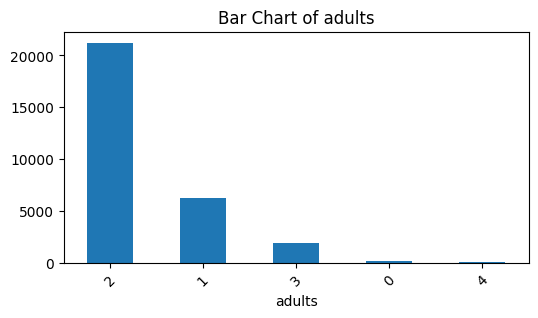

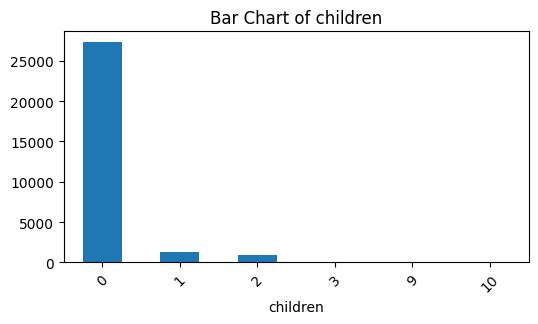

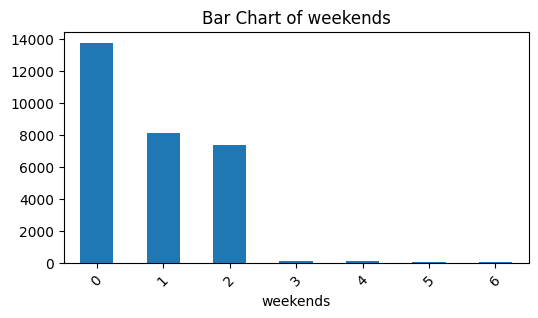

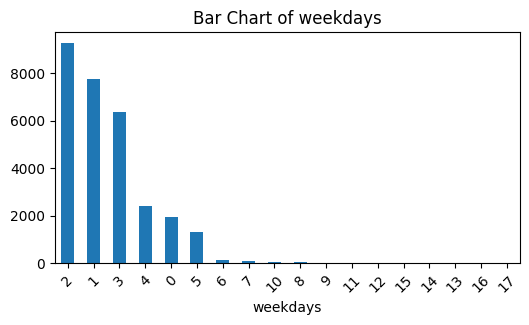

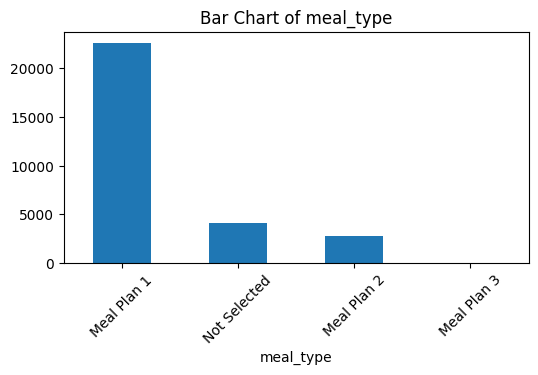

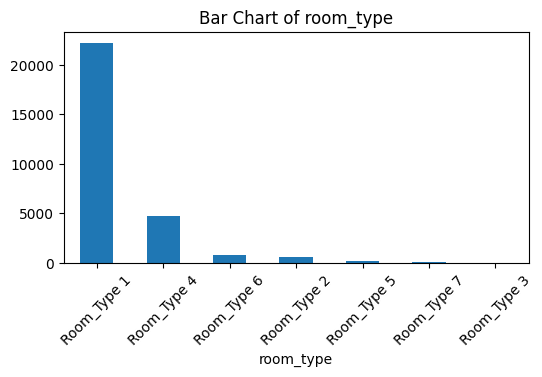

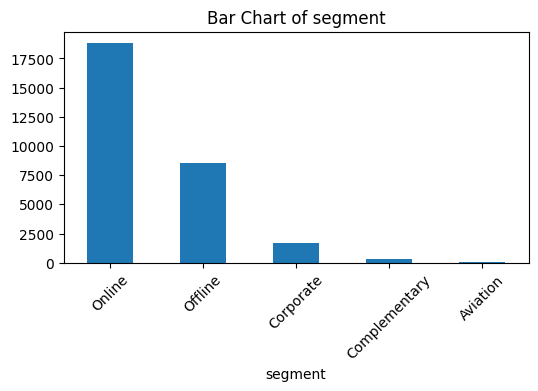

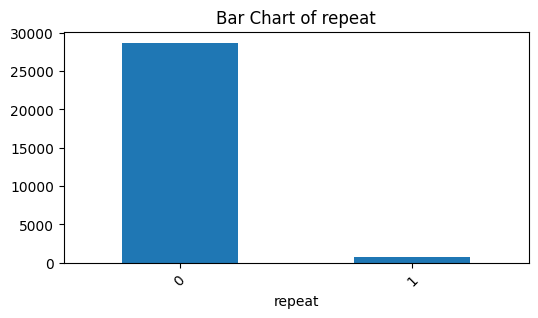

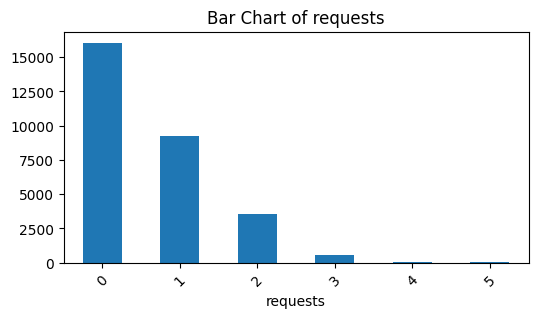

In [15]:
for col in ["adults", "children", "weekends", "weekdays", "meal_type", "room_type", "segment", "repeat", "requests"]:
    plt.figure(figsize=(6, 3))
    train_df[col].value_counts().plot(kind='bar')
    plt.title(f'Bar Chart of {col}')
    plt.xticks(rotation=45)
    plt.show()

### Analysis form EDA

In [16]:
# Adult column - no null values, discrete numerical data (possible: can be remove outliers)
# children column - no null values, discrete numerical data (possible: Should be remove outliers)
# weekends column - no null values, discrete numerical data (possible: Should be remove outliers)
# weekdays column - ... same
# meal type - no null, categorical column, it should encode as one hot encoding and outlier remove
# room_type - null present, categorical column, first needs to remove outlier, then do the imputation, then one hot encode
# arrival - Since the lead_time column actually gives valuable info include this, so this can be dropped.
# lead_time - null present, remove outliers, imputation
# segment - no null, categorical, one hot encode
# repeat - no null, categorical, one hot encode
# price - null present, imputations
# requests - no null, discrete numerical, outliers can be handled
# booking status - target

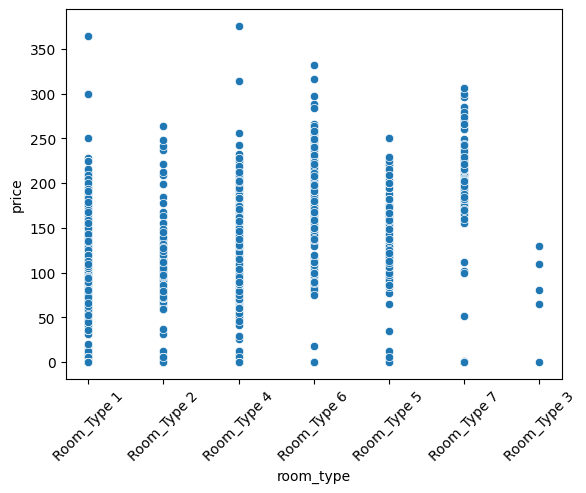

In [17]:
sns.scatterplot(data=train_df, x="room_type", y="price")
plt.xticks(rotation=45)   # You can use 30, 45, 60, 90 etc.
plt.show()

### Handle missing values - Imputation

In [18]:
# Normal imputation based on median is enough for room type
from sklearn.impute import SimpleImputer

med_imp = SimpleImputer(strategy='most_frequent')
median_imp = SimpleImputer(strategy="median")

In [19]:
med_imp.fit(train_df[["room_type"]])

,missing_values,nan
,strategy,'most_frequent'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False


In [20]:
train_df[["room_type"]] = med_imp.transform(train_df[["room_type"]])
test_df[["room_type"]] = med_imp.transform(test_df[["room_type"]])

In [21]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29500 entries, 0 to 29499
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              29500 non-null  int64  
 1   adults          29500 non-null  int64  
 2   children        29500 non-null  int64  
 3   weekends        29500 non-null  int64  
 4   weekdays        29500 non-null  int64  
 5   meal_type       29500 non-null  object 
 6   room_type       29500 non-null  object 
 7   arrival         29500 non-null  object 
 8   lead_time       27805 non-null  float64
 9   segment         29500 non-null  object 
 10  repeat          29500 non-null  int64  
 11  price           27917 non-null  float64
 12  requests        29500 non-null  int64  
 13  booking_status  29500 non-null  int64  
dtypes: float64(2), int64(8), object(4)
memory usage: 3.2+ MB


In [22]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         7000 non-null   int64  
 1   adults     7000 non-null   int64  
 2   children   7000 non-null   int64  
 3   weekends   7000 non-null   int64  
 4   weekdays   7000 non-null   int64  
 5   meal_type  7000 non-null   object 
 6   room_type  7000 non-null   object 
 7   arrival    7000 non-null   object 
 8   lead_time  6588 non-null   float64
 9   segment    7000 non-null   object 
 10  repeat     7000 non-null   int64  
 11  price      6594 non-null   float64
 12  requests   7000 non-null   int64  
dtypes: float64(2), int64(7), object(4)
memory usage: 711.1+ KB


In [23]:
train_df.drop(["arrival"], axis=1, inplace=True)
test_df.drop(["arrival"], axis=1, inplace=True)

In [24]:
median_imp.fit(train_df[["lead_time"]])

,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False


In [25]:
train_df[["lead_time"]] = median_imp.transform(train_df[["lead_time"]])
test_df[["lead_time"]] = median_imp.transform(test_df[["lead_time"]])

In [26]:
median_imp.fit(train_df[["price"]])

,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False


In [27]:
train_df[["price"]] = median_imp.transform(train_df[["price"]])
test_df[["price"]] = median_imp.transform(test_df[["price"]])

In [28]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29500 entries, 0 to 29499
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              29500 non-null  int64  
 1   adults          29500 non-null  int64  
 2   children        29500 non-null  int64  
 3   weekends        29500 non-null  int64  
 4   weekdays        29500 non-null  int64  
 5   meal_type       29500 non-null  object 
 6   room_type       29500 non-null  object 
 7   lead_time       29500 non-null  float64
 8   segment         29500 non-null  object 
 9   repeat          29500 non-null  int64  
 10  price           29500 non-null  float64
 11  requests        29500 non-null  int64  
 12  booking_status  29500 non-null  int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 2.9+ MB


In [29]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         7000 non-null   int64  
 1   adults     7000 non-null   int64  
 2   children   7000 non-null   int64  
 3   weekends   7000 non-null   int64  
 4   weekdays   7000 non-null   int64  
 5   meal_type  7000 non-null   object 
 6   room_type  7000 non-null   object 
 7   lead_time  7000 non-null   float64
 8   segment    7000 non-null   object 
 9   repeat     7000 non-null   int64  
 10  price      7000 non-null   float64
 11  requests   7000 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 656.4+ KB


### Encode categorical columns

In [30]:
from sklearn.preprocessing import OneHotEncoder

one_enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

from sklearn.compose import ColumnTransformer


ct = ColumnTransformer(
    [
        ("onehot", one_enc, ["meal_type", "room_type", "segment"])
    ]
)

In [31]:
one_hot_train = ct.fit_transform(train_df)

one_hot_test = ct.transform(test_df)

one_hot_cols = ct.named_transformers_['onehot'].get_feature_names_out(['meal_type', 'room_type', 'segment'])

one_hot_train_df = pd.DataFrame(data=one_hot_train, columns=one_hot_cols)

one_hot_test_df = pd.DataFrame(data=one_hot_test, columns=one_hot_cols)

In [32]:
train_df = pd.concat([train_df, one_hot_train_df], axis=1)

test_df = pd.concat([test_df, one_hot_test_df], axis=1)

train_df.drop(["room_type", "meal_type", "segment"], axis=1, inplace=True)

test_df.drop(["room_type", "meal_type", "segment"], axis=1, inplace=True)

In [33]:
train_df.isna().sum()

id                        0
adults                    0
children                  0
weekends                  0
weekdays                  0
lead_time                 0
repeat                    0
price                     0
requests                  0
booking_status            0
meal_type_Meal Plan 1     0
meal_type_Meal Plan 2     0
meal_type_Meal Plan 3     0
meal_type_Not Selected    0
room_type_Room_Type 1     0
room_type_Room_Type 2     0
room_type_Room_Type 3     0
room_type_Room_Type 4     0
room_type_Room_Type 5     0
room_type_Room_Type 6     0
room_type_Room_Type 7     0
segment_Aviation          0
segment_Complementary     0
segment_Corporate         0
segment_Offline           0
segment_Online            0
dtype: int64

In [34]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29500 entries, 0 to 29499
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      29500 non-null  int64  
 1   adults                  29500 non-null  int64  
 2   children                29500 non-null  int64  
 3   weekends                29500 non-null  int64  
 4   weekdays                29500 non-null  int64  
 5   lead_time               29500 non-null  float64
 6   repeat                  29500 non-null  int64  
 7   price                   29500 non-null  float64
 8   requests                29500 non-null  int64  
 9   booking_status          29500 non-null  int64  
 10  meal_type_Meal Plan 1   29500 non-null  float64
 11  meal_type_Meal Plan 2   29500 non-null  float64
 12  meal_type_Meal Plan 3   29500 non-null  float64
 13  meal_type_Not Selected  29500 non-null  float64
 14  room_type_Room_Type 1   29500 non-null

In [35]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      7000 non-null   int64  
 1   adults                  7000 non-null   int64  
 2   children                7000 non-null   int64  
 3   weekends                7000 non-null   int64  
 4   weekdays                7000 non-null   int64  
 5   lead_time               7000 non-null   float64
 6   repeat                  7000 non-null   int64  
 7   price                   7000 non-null   float64
 8   requests                7000 non-null   int64  
 9   meal_type_Meal Plan 1   7000 non-null   float64
 10  meal_type_Meal Plan 2   7000 non-null   float64
 11  meal_type_Meal Plan 3   7000 non-null   float64
 12  meal_type_Not Selected  7000 non-null   float64
 13  room_type_Room_Type 1   7000 non-null   float64
 14  room_type_Room_Type 2   7000 non-null   

### Handle duplicates - Drop duplicates

In [36]:
train_df.drop(["id"], axis=1, inplace=True)
test_df.drop(["id"], axis=1, inplace=True)

In [37]:
train_df.duplicated().sum()

np.int64(7675)

In [38]:
train_df = train_df.drop_duplicates()

In [39]:
train_df.shape

(21825, 25)

In [40]:
train_df["booking_status"].isna().sum()

np.int64(0)

### Handle outliers

In [41]:
import pandas as pd

def remove_outliers_iqr(df):
    df_clean = df.copy()
    numeric_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns

    for col in numeric_cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Keep only values within bounds
        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]

    return df_clean


In [42]:
train_df = remove_outliers_iqr(train_df)

In [43]:
train_df.shape

(6520, 25)

### Scale numerical columns

In [44]:
X = train_df.drop(["booking_status"], axis=1)
y = train_df["booking_status"]

In [45]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_norm = scaler.fit_transform(X)

In [46]:
X_test_norm = scaler.transform(test_df)

In [47]:
X_norm_df = pd.DataFrame(data=X_norm, columns=X.columns)

In [48]:
X_test_df = pd.DataFrame(data=X_test_norm, columns=X.columns)

In [49]:
X_norm_df.head()

,adults,children,weekends,weekdays,lead_time,repeat,price,requests,meal_type_Meal Plan 1,meal_type_Meal Plan 2,...,room_type_Room_Type 3,room_type_Room_Type 4,room_type_Room_Type 5,room_type_Room_Type 6,room_type_Room_Type 7,segment_Aviation,segment_Complementary,segment_Corporate,segment_Offline,segment_Online
0,0.0,0.0,1.245302,0.518097,1.475536,0.0,-1.095333,-0.986852,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.686517,-1.686517
1,0.0,0.0,1.245302,0.518097,0.886748,0.0,-0.994256,-0.986852,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.592938,0.592938
2,0.0,0.0,0.061720,-0.265842,-0.204240,0.0,-0.033809,1.863326,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.592938,0.592938
3,0.0,0.0,-1.121861,-1.049780,-0.966200,0.0,-1.062229,-0.986852,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.686517,-1.686517
4,0.0,0.0,1.245302,2.085973,-0.896931,0.0,0.066385,1.863326,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.592938,0.592938


In [50]:
X_test_df.head()

,adults,children,weekends,weekdays,lead_time,repeat,price,requests,meal_type_Meal Plan 1,meal_type_Meal Plan 2,...,room_type_Room_Type 3,room_type_Room_Type 4,room_type_Room_Type 5,room_type_Room_Type 6,room_type_Room_Type 7,segment_Aviation,segment_Complementary,segment_Corporate,segment_Offline,segment_Online
0,0.0,1.0,0.061720,-1.833718,-1.156691,0.0,-0.311880,3.288415,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.592938,0.592938
1,0.0,0.0,0.061720,-0.265842,-1.052787,0.0,-2.136112,-0.986852,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.686517,-1.686517
2,0.0,0.0,1.245302,-0.265842,-0.793028,0.0,-0.082361,0.438237,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.592938,0.592938
3,0.0,0.0,-1.121861,0.518097,-0.810345,0.0,1.350806,-0.986852,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.592938,0.592938
4,0.0,1.0,-1.121861,-0.265842,-1.052787,0.0,4.609530,1.863326,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.592938,0.592938


In [51]:
X_norm_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6520 entries, 0 to 6519
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   adults                  6520 non-null   float64
 1   children                6520 non-null   float64
 2   weekends                6520 non-null   float64
 3   weekdays                6520 non-null   float64
 4   lead_time               6520 non-null   float64
 5   repeat                  6520 non-null   float64
 6   price                   6520 non-null   float64
 7   requests                6520 non-null   float64
 8   meal_type_Meal Plan 1   6520 non-null   float64
 9   meal_type_Meal Plan 2   6520 non-null   float64
 10  meal_type_Meal Plan 3   6520 non-null   float64
 11  meal_type_Not Selected  6520 non-null   float64
 12  room_type_Room_Type 1   6520 non-null   float64
 13  room_type_Room_Type 2   6520 non-null   float64
 14  room_type_Room_Type 3   6520 non-null   

In [52]:
X_test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   adults                  7000 non-null   float64
 1   children                7000 non-null   float64
 2   weekends                7000 non-null   float64
 3   weekdays                7000 non-null   float64
 4   lead_time               7000 non-null   float64
 5   repeat                  7000 non-null   float64
 6   price                   7000 non-null   float64
 7   requests                7000 non-null   float64
 8   meal_type_Meal Plan 1   7000 non-null   float64
 9   meal_type_Meal Plan 2   7000 non-null   float64
 10  meal_type_Meal Plan 3   7000 non-null   float64
 11  meal_type_Not Selected  7000 non-null   float64
 12  room_type_Room_Type 1   7000 non-null   float64
 13  room_type_Room_Type 2   7000 non-null   float64
 14  room_type_Room_Type 3   7000 non-null   

In [53]:
model_names = []
model_scores_train = []

### Model 1

In [ ]:
# ! pip install catboost

In [56]:
from catboost import CatBoostClassifier


model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=8,
    eval_metric='Accuracy',
    verbose=100
)

model.fit(X_norm_df, y)

0:	learn: 0.8070552	total: 60.1ms	remaining: 30s
100:	learn: 0.8446319	total: 570ms	remaining: 2.25s
200:	learn: 0.8601227	total: 1.03s	remaining: 1.54s
300:	learn: 0.8791411	total: 1.49s	remaining: 987ms
400:	learn: 0.8904908	total: 1.98s	remaining: 489ms
499:	learn: 0.9029141	total: 2.45s	remaining: 0us


CatBoostClassifier(depth=8, eval_metric='Accuracy', iterations=500, learning_rate=0.05, verbose=100)

In [57]:
y_test_pred = model.predict(X_test_df)

In [58]:
pred_df = pd.DataFrame({"id": range(len(y_test_pred)), "booking_status": y_test_pred})

In [59]:
pred_df.to_csv('../outputs/catboost_classifier.csv', index=False) 

In [60]:
from sklearn.metrics import accuracy_score

train_score = accuracy_score(y_pred=model.predict(X_norm_df), y_true=y)
print(train_score)
model_names.append("Catboost")
model_scores_train.append(train_score)

0.9029141104294478


### Model 2

In [61]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)


In [63]:
model.fit(X_norm_df, y)
y_pred = model.predict(X_test_df)
pred_df = pd.DataFrame({"id": range(len(y_pred)), "booking_status": y_pred})

pred_df.to_csv("../outputs/xgboost_classifier.csv", index=False)

In [64]:
from sklearn.metrics import accuracy_score

train_score = accuracy_score(y_pred=model.predict(X_norm_df), y_true=y)
print(train_score)
model_names.append("XGBoost")
model_scores_train.append(train_score)

0.8838957055214723


### Model 3

In [65]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight='balanced',
    random_state=42
)


In [66]:
model.fit(X_norm_df, y)
y_pred = model.predict(X_test_df)
pred_df = pd.DataFrame({"id": range(len(y_pred)), "booking_status": y_pred})

pred_df.to_csv("../outputs/randomforest_classifier.csv", index=False)

In [67]:
from sklearn.metrics import accuracy_score

train_score = accuracy_score(y_pred=model.predict(X_norm_df), y_true=y)
print(train_score)
model_names.append("RandomForest")
model_scores_train.append(train_score)

0.9904907975460123


#### Model 4

In [68]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report


In [69]:
log_reg = LogisticRegression(max_iter=2000)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    random_state=42
)

gb = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

svm = SVC(probability=True, kernel='rbf', C=3, gamma='scale')

knn = KNeighborsClassifier(n_neighbors=7)


In [70]:
scaled_models = Pipeline([
    ('scaler', StandardScaler()),
    ('model', VotingClassifier(
        estimators=[
            ('lr', log_reg),
            ('svm', svm),
            ('knn', knn),
        ],
        voting='soft'
    ))
])


In [71]:
model = VotingClassifier(
    estimators=[
        ('scaled', scaled_models),
        ('rf', rf),
        ('gb', gb)
    ],
    voting='soft'   # soft voting gives best accuracy
)


In [72]:
model.fit(X_norm_df, y)
y_pred = model.predict(X_test_df)
pred_df = pd.DataFrame({"id": range(len(y_pred)), "booking_status": y_pred})

pred_df.to_csv("../outputs/voting_ensemble_classifier.csv", index=False)

In [73]:
from sklearn.metrics import accuracy_score

train_score = accuracy_score(y_pred=model.predict(X_norm_df), y_true=y)
print(train_score)
model_names.append("Votting_Classifier")
model_scores_train.append(train_score)

0.8912576687116565


#### Model 5

In [74]:
from sklearn.ensemble import StackingClassifier, RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report


# Scaled models (SVM + KNN)
svm_model = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(probability=True, kernel='rbf', C=3, gamma='scale'))
])

knn_model = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=7))
])

# Tree-based models (no scaling needed)
rf_model = RandomForestClassifier(
    n_estimators=350,
    max_depth=None,
    random_state=42
)

gb_model = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

et_model = ExtraTreesClassifier(
    n_estimators=300,
    random_state=42
)

# Stacking ensemble
model = StackingClassifier(
    estimators=[
        ('rf', rf_model),
        ('gb', gb_model),
        ('et', et_model),
        ('svm', svm_model),
        ('knn', knn_model),
    ],
    final_estimator=LogisticRegression(max_iter=2000),
    stack_method='predict_proba',
    n_jobs=-1
)

In [75]:
model.fit(X_norm_df, y)
y_pred = model.predict(X_test_df)
pred_df = pd.DataFrame({"id": range(len(y_pred)), "booking_status": y_pred})

pred_df.to_csv("../outputs/stacking_classifier.csv", index=False)

In [76]:
from sklearn.metrics import accuracy_score

train_score = accuracy_score(y_pred=model.predict(X_norm_df), y_true=y)
print(train_score)
model_names.append("StackClassifier")
model_scores_train.append(train_score)

0.8579754601226994


### Model 6

In [77]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(
    criterion='gini',        # or 'entropy'
    max_depth=8,             # prevents overfitting
    min_samples_split=10,    # avoids very small splits
    min_samples_leaf=4,      # ensures stability
    max_features=None,       # use all features
    class_weight=None,       # or 'balanced' if imbalance
    random_state=42
)

In [78]:
model.fit(X_norm_df, y)
y_pred = model.predict(X_test_df)
pred_df = pd.DataFrame({"id": range(len(y_pred)), "booking_status": y_pred})

pred_df.to_csv("../outputs/decisiontree_classifier.csv", index=False)

In [79]:
from sklearn.metrics import accuracy_score

train_score = accuracy_score(y_pred=model.predict(X_norm_df), y_true=y)
print(train_score)
model_names.append("DecisionTree")
model_scores_train.append(train_score)

0.849079754601227


### Model 7

In [80]:
from sklearn.linear_model import LogisticRegression

In [81]:
model = LogisticRegression(
    penalty='l2',
    C=1.0,                 # regularization strength
    solver='lbfgs',        # good for medium-sized datasets
    max_iter=1000,
    class_weight=None,     # or 'balanced'
    random_state=42
)

In [83]:
model.fit(X_norm_df, y)
y_pred = model.predict(X_test_df)
pred_df = pd.DataFrame({"id": range(len(y_pred)), "booking_status": y_pred})

pred_df.to_csv("../outputs/logistic_classifier.csv", index=False)

In [84]:
from sklearn.metrics import accuracy_score

train_score = accuracy_score(y_pred=model.predict(X_norm_df), y_true=y)
print(train_score)
model_names.append("LogisticRegression")
model_scores_train.append(train_score)

0.8038343558282208


### Analyse the train scores for models

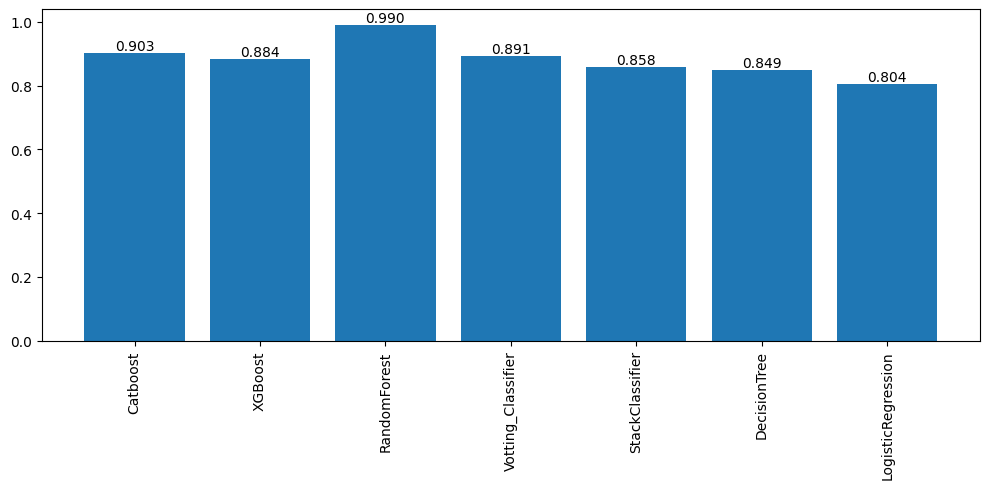

In [85]:
plt.figure(figsize=(10, 5))

bars = plt.bar(model_names, model_scores_train)

plt.xticks(rotation=90)

# Add value labels on each bar
plt.bar_label(bars, fmt='%.3f')   # shows score with 3 decimals

plt.tight_layout()
plt.show()


### Hyper parameter tuning Model 1

In [86]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)

param_grid = {
    'n_estimators': [100, 500],
    'max_depth': [None, 10, 30],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [1, 2, 4],
}

model = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    verbose=1
)

In [87]:
model.fit(X_norm_df, y)
y_pred = model.predict(X_test_df)
pred_df = pd.DataFrame({"id": range(len(y_pred)), "booking_status": y_pred})

pred_df.to_csv("../outputs/hyper_tuned_randomforest_classifier.csv", index=False)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


In [88]:
from sklearn.metrics import accuracy_score

train_score = accuracy_score(y_pred=model.predict(X_norm_df), y_true=y)
print(train_score)
model_names.append("Hyp-RandomForest")
model_scores_train.append(train_score)

0.8575153374233129


### Hyper parameter tuning for Model 2

In [89]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

lr = LogisticRegression(max_iter=1000, random_state=42)

param_grid_lr = {
    'solver': ['liblinear', 'saga'],     # supports L1 + L2
    'penalty': ['l1', 'l2'],
    'C': [0.01, 0.1, 1, 10, 50]
}

model = GridSearchCV(
    estimator=lr,
    param_grid=param_grid_lr,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    verbose=1
)

In [90]:
model.fit(X_norm_df, y)
y_pred = model.predict(X_test_df)
pred_df = pd.DataFrame({"id": range(len(y_pred)), "booking_status": y_pred})

pred_df.to_csv("../outputs/hyper_tuned_logistic_classifier.csv", index=False)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


In [91]:
from sklearn.metrics import accuracy_score

train_score = accuracy_score(y_pred=model.predict(X_norm_df), y_true=y)
print(train_score)
model_names.append("Hyp-Logistic")
model_scores_train.append(train_score)

0.803680981595092


### Hyper parameter tuning - Model 3

In [92]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

dt = DecisionTreeClassifier(random_state=42)

param_grid_dt = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [None, 5, 10, 15, 20, 30],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [None, 'sqrt', 'log2']
}

model = GridSearchCV(
    estimator=dt,
    param_grid=param_grid_dt,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    verbose=1
)

In [93]:
model.fit(X_norm_df, y)
y_pred = model.predict(X_test_df)
pred_df = pd.DataFrame({"id": range(len(y_pred)), "booking_status": y_pred})

pred_df.to_csv("../outputs/hyper_tuned_decisiontree_classifier.csv", index=False)

Fitting 5 folds for each of 864 candidates, totalling 4320 fits


In [94]:
from sklearn.metrics import accuracy_score

train_score = accuracy_score(y_pred=model.predict(X_norm_df), y_true=y)
print(train_score)
model_names.append("Hyp-DecisionTree")
model_scores_train.append(train_score)

0.8338957055214724


### Model Comparsions

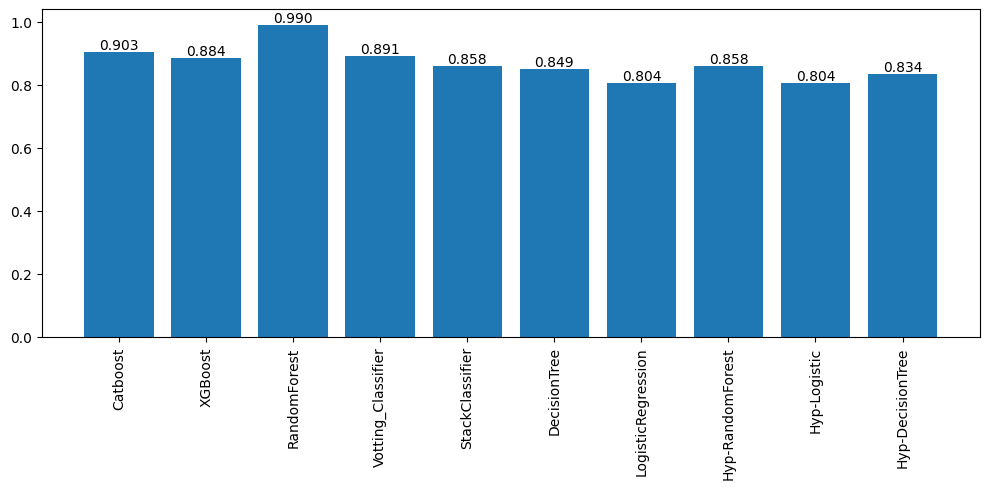

In [97]:
plt.figure(figsize=(10, 5))

bars = plt.bar(model_names, model_scores_train)

plt.xticks(rotation=90)

# Add value labels on each bar
plt.bar_label(bars, fmt='%.3f')   # shows score with 3 decimals

plt.tight_layout()
plt.savefig("../outputs/model_comparison.png")
plt.show()
